send finns: True
rec finns : True

Vald modell: Bohus
R_ref = 1.257525 Ω
X_ref = 6.555000 Ω
alpha = 0.00403 1/K
T_ref = 20.0 °C


C:\Users\lundi\AppData\Local\Temp\ipykernel_91324\3043001317.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
C:\Users\lundi\AppData\Local\Temp\ipykernel_91324\3043001317.py:134: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")



Joined dataframe:
rows: 7669
start: 2025-12-11 15:25:02.469999 slut: 2025-12-11 15:27:32.450000
fs = 50.00250012500625 Hz
smooth_window = 100

=== Baseline actual ===


,Phase,Case,delta_deg,kU,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg
0,L1,actual,0.0,1.0,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,0.898770,0.984417
1,L2,actual,0.0,1.0,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,0.875989,0.954564
2,L3,actual,0.0,1.0,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,0.898759,1.459783



=== Bästa COMMON-kalibrering ===
{'Mode': 'common', 'delta_deg': np.float64(8.881784197001252e-16), 'kU': np.float64(0.9999999999999994), 'J': np.float64(0.001720799736574517), 'X_mean_L1': np.float64(6.7164459320953265), 'X_mean_L2': np.float64(6.244582347759263), 'X_mean_L3': np.float64(6.713965892858213), 'X_std_L1': np.float64(0.020233248464104556), 'X_std_L2': np.float64(0.01877213471284984), 'X_std_L3': np.float64(0.020318154213595504)}

=== Kalibrerat resultat ===


,Phase,Case,delta_deg,kU,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg
0,L1,x_anchor_common,8.881784e-16,1.0,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,0.898770,0.984417
1,L2,x_anchor_common,8.881784e-16,1.0,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,0.875989,0.954564
2,L3,x_anchor_common,8.881784e-16,1.0,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,0.898759,1.459783


,Phase,Case,delta_deg,kU,R_mean_Ohm,R_std_Ohm,X_mean_Ohm,X_std_Ohm,T_mean_C,T_std_C,dU_mean_deg,dI_mean_deg
0,L1,actual,0.000000e+00,1.0,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,0.898770,0.984417
1,L2,actual,0.000000e+00,1.0,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,0.875989,0.954564
2,L3,actual,0.000000e+00,1.0,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,0.898759,1.459783
3,L1,x_anchor_common,8.881784e-16,1.0,1.784722,0.013036,6.716446,0.020233,124.028320,2.572391,0.898770,0.984417
4,L2,x_anchor_common,8.881784e-16,1.0,1.114641,0.011302,6.244582,0.018772,-8.194314,2.230181,0.875989,0.954564
5,L3,x_anchor_common,8.881784e-16,1.0,0.509709,0.014160,6.713966,0.020318,-127.561448,2.794064,0.898759,1.459783



Sparat till: C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\kan_X_anvandas_som_baslinje_for_att_forbattra_R_och_temperaturtolkningen


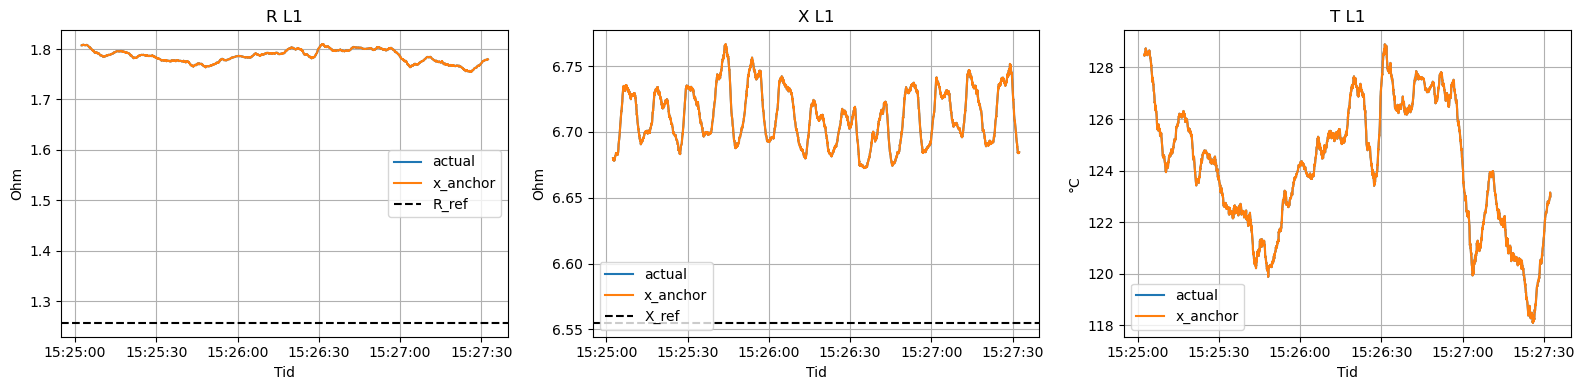

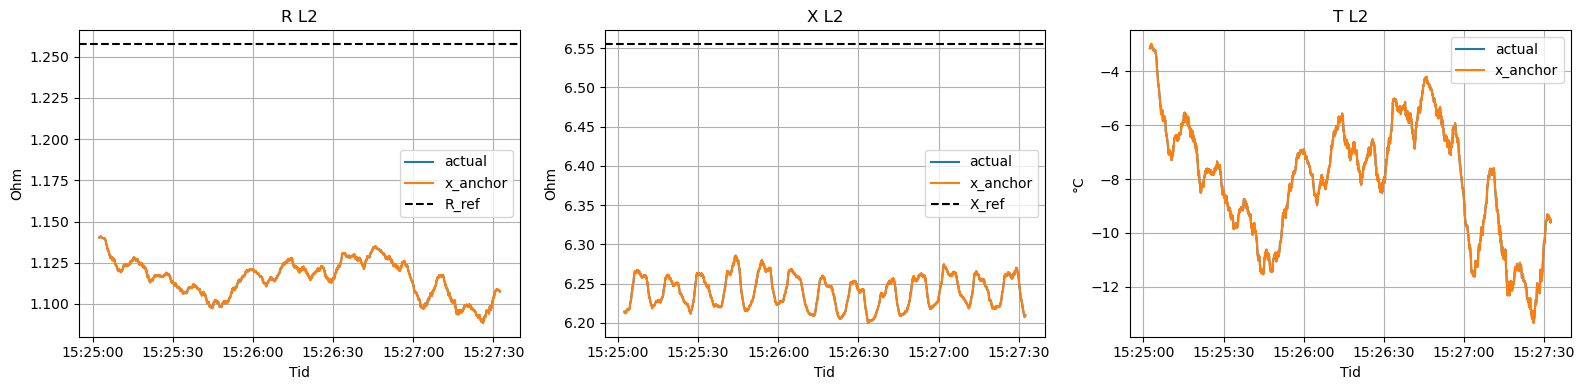

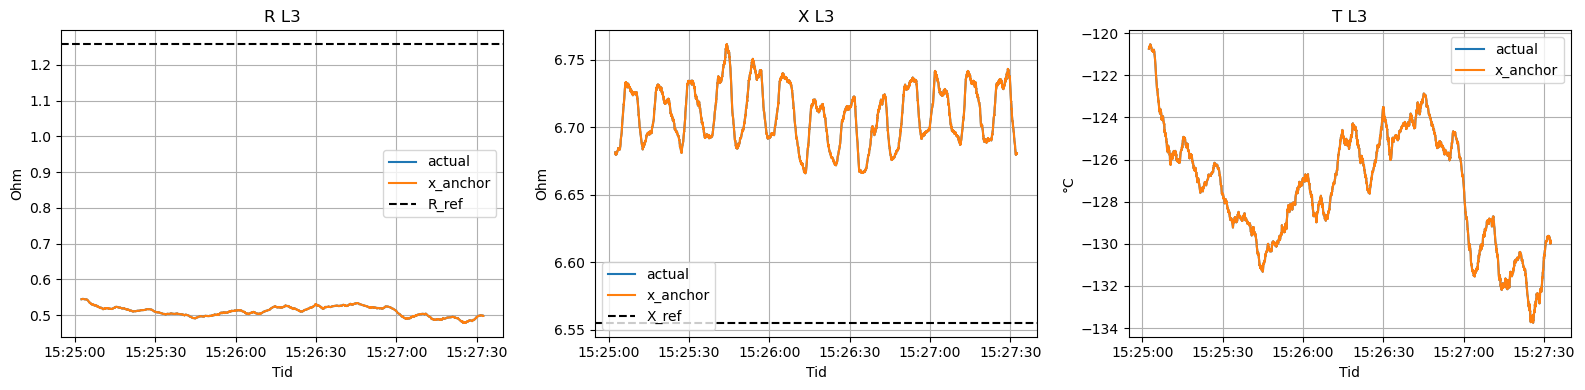

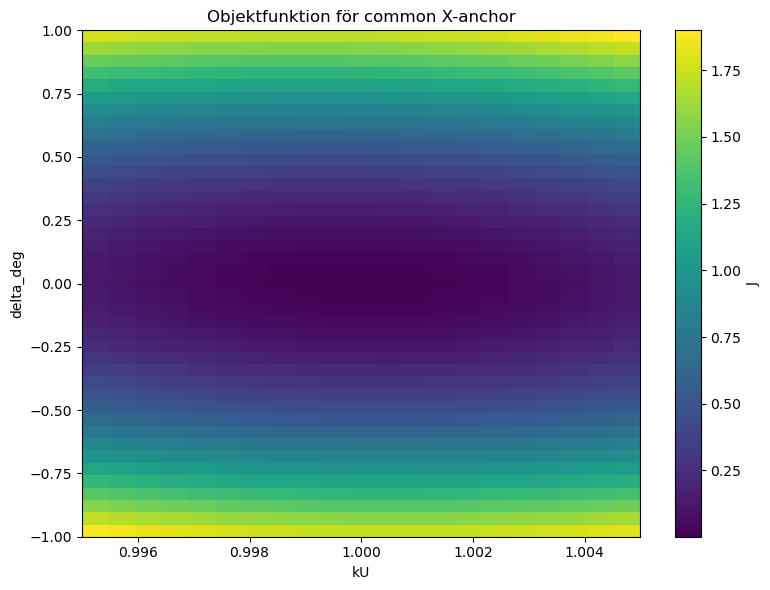

In [5]:
# ============================================================
# X AS ANCHOR: KALIBRERA Z-drop MED X_ref SOM MÅL
# - Läs send/rec
# - Bygg df_joined
# - Beräkna actual Z-drop
# - Sök liten korrigering i mottagarspänning:
#     * deltaU (grader)
#     * kU (magnitudskala)
# - välj den lösning som gör X_est nära X_ref
# - räkna om R och T
# ============================================================

import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.options.mode.chained_assignment = None

# ============================================================
# FILVÄGAR OCH BLADNAMN
# ============================================================

send_file = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\send-station.xlsx")
rec_file  = Path(r"C:\Users\lundi\OneDrive\Skóli\Svíþjóð\Exjobb\Arbetet\Källor\phasor_dlr-main\phasor_dlr-main\data\rec-station.xlsx")

keyS_sheet  = "K-nyckel"
dataS_sheet = "Station_K_3x15000"

keyR_sheet  = "F-nyckel"
dataR_sheet = "Station_F_3x15000"

print("send finns:", send_file.exists())
print("rec finns :", rec_file.exists())

# ============================================================
# MODELLVAL
# ============================================================

MODEL = "Bohus"   # byt till "Gota" om du vill

MODELS = {
    "Bohus": {
        "length_km": 17.25,
        "RAC_ohm_per_km": 0.0729,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
    "Gota": {
        "length_km": 21.95,
        "RAC_ohm_per_km": 0.0348,
        "alpha": 0.00403,
        "T_ref_C": 20.0,
        "X_ohm_per_km": 0.38,
    },
}

model = MODELS[MODEL]
R_ref = model["RAC_ohm_per_km"] * model["length_km"]
X_ref = model["X_ohm_per_km"] * model["length_km"]
alpha = model["alpha"]
T_ref = model["T_ref_C"]

print(f"\nVald modell: {MODEL}")
print(f"R_ref = {R_ref:.6f} Ω")
print(f"X_ref = {X_ref:.6f} Ω")
print(f"alpha = {alpha:.5f} 1/K")
print(f"T_ref = {T_ref:.1f} °C")

# ============================================================
# INSTÄLLNINGAR
# ============================================================

# Hur ska vi kalibrera?
CAL_MODE = "common"      # "common" eller "per_phase"

# Sökintervall
delta_grid = np.arange(-1.0, 1.0001, 0.05)      # grader
kU_grid = np.arange(0.995, 1.0051, 0.0005)      # ±0.5%

# Vilken nämnare i Z-drop?
DENOM_MODE = "avg"       # "avg", "send", "rec"

# smoothing före division
smooth_seconds = 2.0
min_current_A = 50.0

# viktning i objektfunktionen
w_xmatch = 1.0
w_spread = 0.25
w_reg_delta = 0.02
w_reg_k = 0.02

# regularisering: hur "dyra" stora korrigeringar ska vara
sigma_delta_deg = 0.2
sigma_k = 0.002   # 0.2 %

VERSION = f"{MODEL.lower()}_x_anchor_{CAL_MODE}_{DENOM_MODE}"

# ============================================================
# HJÄLPFUNKTIONER
# ============================================================

def safe_folder_name(name):
    return re.sub(r'[<>:"/\\|?*]', '_', name).strip().rstrip(".")

def wrap_angle_deg(angle_deg):
    return (angle_deg + 180.0) % 360.0 - 180.0

def circular_mean_deg(angle_deg):
    angle_deg = np.asarray(angle_deg, dtype=float)
    angle_deg = angle_deg[~np.isnan(angle_deg)]
    if len(angle_deg) == 0:
        return np.nan
    angle_rad = np.deg2rad(angle_deg)
    return np.rad2deg(np.angle(np.mean(np.exp(1j * angle_rad))))

def read_key_table_safe(filename, sheetname):
    T = pd.read_excel(filename, sheet_name=sheetname, header=None)
    T = T.iloc[:, :2].copy()
    T.columns = ["Parameter", "ID"]
    T = T.dropna(how="all")
    T["Parameter"] = T["Parameter"].astype(str).str.strip()
    T["ID"] = T["ID"].astype(str).str.strip()
    return T

def read_data_table_safe(filename, sheetname):
    D = pd.read_excel(filename, sheet_name=sheetname, header=None)
    D = D.iloc[:, :3].copy()
    D.columns = ["Timestamp", "ID", "Value"]
    D["Timestamp"] = pd.to_datetime(D["Timestamp"], errors="coerce")
    D["ID"] = D["ID"].astype(str).str.strip()
    D["Value"] = (
        D["Value"]
        .astype(str)
        .str.strip()
        .str.replace(",", ".", regex=False)
    )
    D["Value"] = pd.to_numeric(D["Value"], errors="coerce")
    D = D.dropna(subset=["Timestamp"])
    return D

def complex_from_mag_ang(mag, ang_deg):
    return mag * np.exp(1j * np.deg2rad(ang_deg))

def rolling_complex_mean(z, window):
    z_re = pd.Series(np.real(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    z_im = pd.Series(np.imag(z), index=z.index).rolling(window=window, center=True, min_periods=1).mean()
    return z_re + 1j * z_im

def add_mean_line(ax, y, color=None, label_prefix="mean", circular=False):
    if circular:
        mean_val = circular_mean_deg(y)
    else:
        mean_val = np.nanmean(y)
    ax.axhline(mean_val, linestyle="--", linewidth=1.0, color=color, alpha=0.8,
               label=f"{label_prefix} = {mean_val:.3f}")
    return mean_val

def build_joined_dataframe():
    keyS = read_key_table_safe(send_file, keyS_sheet)
    keyR = read_key_table_safe(rec_file, keyR_sheet)

    send = read_data_table_safe(send_file, dataS_sheet)
    rec  = read_data_table_safe(rec_file, dataR_sheet)

    send = send.merge(keyS, on="ID", how="inner")
    rec  = rec.merge(keyR, on="ID", how="inner")

    wideS = send.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")
    wideR = rec.pivot_table(index="Timestamp", columns="Parameter", values="Value", aggfunc="first")

    wideS = wideS.add_suffix("_S").sort_index()
    wideR = wideR.add_suffix("_R").sort_index()

    df_joined = wideS.join(wideR, how="inner").copy()

    required_cols = []
    for ph in ["L1", "L2", "L3"]:
        required_cols += [
            f"U{ph}MAG_S", f"U{ph}ANG_S", f"U{ph}MAG_R", f"U{ph}ANG_R",
            f"I{ph}MAG_S", f"I{ph}ANG_S", f"I{ph}MAG_R", f"I{ph}ANG_R",
        ]

    missing = [c for c in required_cols if c not in df_joined.columns]
    if missing:
        raise ValueError(f"Saknade kolumner: {missing}")

    df_joined = df_joined.dropna(subset=required_cols).copy()

    angle_cols = [c for c in df_joined.columns if "ANG" in c]
    for c in angle_cols:
        df_joined = df_joined[(df_joined[c] >= -180) & (df_joined[c] <= 180)]

    return df_joined

def compute_Zdrop_for_phase(df, ph, delta_deg=0.0, kU=1.0):
    # rådata
    U_mag_S = df[f"U{ph}MAG_S"]
    U_ang_S = df[f"U{ph}ANG_S"]
    U_mag_R = df[f"U{ph}MAG_R"]
    U_ang_R = df[f"U{ph}ANG_R"]

    I_mag_S = df[f"I{ph}MAG_S"]
    I_ang_S = df[f"I{ph}ANG_S"]
    I_mag_R = df[f"I{ph}MAG_R"]
    I_ang_R = df[f"I{ph}ANG_R"]

    # korrigera mottagarström 180°
    I_ang_R_corr = wrap_angle_deg(I_ang_R + 180.0)

    Vs = complex_from_mag_ang(U_mag_S, U_ang_S)
    Vr = complex_from_mag_ang(kU * U_mag_R, wrap_angle_deg(U_ang_R + delta_deg))

    Is = complex_from_mag_ang(I_mag_S, I_ang_S)
    Ir = complex_from_mag_ang(I_mag_R, I_ang_R_corr)

    # välj nämnare
    if DENOM_MODE == "avg":
        I_den = 0.5 * (Is + Ir)
    elif DENOM_MODE == "send":
        I_den = Is
    elif DENOM_MODE == "rec":
        I_den = Ir
    else:
        raise ValueError("DENOM_MODE måste vara avg, send eller rec")

    dV = Vs - Vr

    # smoothing
    dV_sm = rolling_complex_mean(pd.Series(dV, index=df.index), smooth_window)
    I_sm  = rolling_complex_mean(pd.Series(I_den, index=df.index), smooth_window)

    valid = np.abs(I_sm) > min_current_A

    Z_est = pd.Series(np.nan + 1j*np.nan, index=df.index, dtype=complex)
    Z_est.loc[valid] = dV_sm.loc[valid] / I_sm.loc[valid]

    R_est = np.real(Z_est)
    X_est = np.imag(Z_est)
    T_est = ((R_est / R_ref) - 1.0) / alpha + T_ref

    return {
        "R": R_est,
        "X": X_est,
        "T": T_est,
        "dU": wrap_angle_deg(U_ang_S - wrap_angle_deg(U_ang_R + delta_deg)),
        "dI": wrap_angle_deg(I_ang_S - I_ang_R_corr),
    }

def objective_phase(df, ph, delta_deg, kU):
    res = compute_Zdrop_for_phase(df, ph, delta_deg=delta_deg, kU=kU)
    x_mean = np.nanmean(res["X"])
    x_std = np.nanstd(res["X"])

    J = (
        w_xmatch * ((x_mean - X_ref) / X_ref) ** 2 +
        w_spread * (x_std / X_ref) ** 2 +
        w_reg_delta * (delta_deg / sigma_delta_deg) ** 2 +
        w_reg_k * ((kU - 1.0) / sigma_k) ** 2
    )
    return J, x_mean, x_std

def objective_common(df, delta_deg, kU):
    vals = []
    for ph in ["L1", "L2", "L3"]:
        res = compute_Zdrop_for_phase(df, ph, delta_deg=delta_deg, kU=kU)
        x_mean = np.nanmean(res["X"])
        x_std = np.nanstd(res["X"])
        vals.append((x_mean, x_std))

    x_means = np.array([v[0] for v in vals])
    x_stds = np.array([v[1] for v in vals])

    J = (
        w_xmatch * np.mean(((x_means - X_ref) / X_ref) ** 2) +
        w_spread * np.mean((x_stds / X_ref) ** 2) +
        0.5 * np.mean(((x_means - np.mean(x_means)) / X_ref) ** 2) +
        w_reg_delta * (delta_deg / sigma_delta_deg) ** 2 +
        w_reg_k * ((kU - 1.0) / sigma_k) ** 2
    )
    return J, x_means, x_stds

# ============================================================
# 1. BYGG DATASET
# ============================================================

df_joined = build_joined_dataframe()

dt = df_joined.index.to_series().diff().dropna().dt.total_seconds()
fs = 1.0 / dt.median()
smooth_window = int(round(smooth_seconds * fs))

print("\nJoined dataframe:")
print("rows:", len(df_joined))
print("start:", df_joined.index.min(), "slut:", df_joined.index.max())
print("fs =", fs, "Hz")
print("smooth_window =", smooth_window)

# ============================================================
# 2. ACTUAL BASELINE
# ============================================================

baseline_rows = []
baseline_outputs = {}

for ph in ["L1", "L2", "L3"]:
    res = compute_Zdrop_for_phase(df_joined, ph, delta_deg=0.0, kU=1.0)
    baseline_outputs[ph] = res
    baseline_rows.append({
        "Phase": ph,
        "Case": "actual",
        "delta_deg": 0.0,
        "kU": 1.0,
        "R_mean_Ohm": np.nanmean(res["R"]),
        "R_std_Ohm": np.nanstd(res["R"]),
        "X_mean_Ohm": np.nanmean(res["X"]),
        "X_std_Ohm": np.nanstd(res["X"]),
        "T_mean_C": np.nanmean(res["T"]),
        "T_std_C": np.nanstd(res["T"]),
        "dU_mean_deg": circular_mean_deg(res["dU"]),
        "dI_mean_deg": circular_mean_deg(res["dI"]),
    })

baseline_df = pd.DataFrame(baseline_rows)
print("\n=== Baseline actual ===")
display(baseline_df)

# ============================================================
# 3. GRID SEARCH
# ============================================================

search_records = []

if CAL_MODE == "common":
    best = None
    for delta in delta_grid:
        for kU in kU_grid:
            J, x_means, x_stds = objective_common(df_joined, delta, kU)
            rec = {
                "Mode": "common",
                "delta_deg": delta,
                "kU": kU,
                "J": J,
                "X_mean_L1": x_means[0],
                "X_mean_L2": x_means[1],
                "X_mean_L3": x_means[2],
                "X_std_L1": x_stds[0],
                "X_std_L2": x_stds[1],
                "X_std_L3": x_stds[2],
            }
            search_records.append(rec)
            if best is None or J < best["J"]:
                best = rec

    search_df = pd.DataFrame(search_records)
    best_delta = best["delta_deg"]
    best_kU = best["kU"]

    print("\n=== Bästa COMMON-kalibrering ===")
    print(best)

    calibrated_rows = []
    calibrated_outputs = {}

    for ph in ["L1", "L2", "L3"]:
        res = compute_Zdrop_for_phase(df_joined, ph, delta_deg=best_delta, kU=best_kU)
        calibrated_outputs[ph] = res
        calibrated_rows.append({
            "Phase": ph,
            "Case": "x_anchor_common",
            "delta_deg": best_delta,
            "kU": best_kU,
            "R_mean_Ohm": np.nanmean(res["R"]),
            "R_std_Ohm": np.nanstd(res["R"]),
            "X_mean_Ohm": np.nanmean(res["X"]),
            "X_std_Ohm": np.nanstd(res["X"]),
            "T_mean_C": np.nanmean(res["T"]),
            "T_std_C": np.nanstd(res["T"]),
            "dU_mean_deg": circular_mean_deg(res["dU"]),
            "dI_mean_deg": circular_mean_deg(res["dI"]),
        })

    calibrated_df = pd.DataFrame(calibrated_rows)

elif CAL_MODE == "per_phase":
    search_df_list = []
    calibrated_rows = []
    calibrated_outputs = {}
    best_dict = {}

    for ph in ["L1", "L2", "L3"]:
        best = None
        local_records = []

        for delta in delta_grid:
            for kU in kU_grid:
                J, x_mean, x_std = objective_phase(df_joined, ph, delta, kU)
                rec = {
                    "Mode": "per_phase",
                    "Phase": ph,
                    "delta_deg": delta,
                    "kU": kU,
                    "J": J,
                    "X_mean": x_mean,
                    "X_std": x_std,
                }
                local_records.append(rec)
                if best is None or J < best["J"]:
                    best = rec

        local_df = pd.DataFrame(local_records)
        search_df_list.append(local_df)
        best_dict[ph] = best

        res = compute_Zdrop_for_phase(df_joined, ph, delta_deg=best["delta_deg"], kU=best["kU"])
        calibrated_outputs[ph] = res

        calibrated_rows.append({
            "Phase": ph,
            "Case": "x_anchor_per_phase",
            "delta_deg": best["delta_deg"],
            "kU": best["kU"],
            "R_mean_Ohm": np.nanmean(res["R"]),
            "R_std_Ohm": np.nanstd(res["R"]),
            "X_mean_Ohm": np.nanmean(res["X"]),
            "X_std_Ohm": np.nanstd(res["X"]),
            "T_mean_C": np.nanmean(res["T"]),
            "T_std_C": np.nanstd(res["T"]),
            "dU_mean_deg": circular_mean_deg(res["dU"]),
            "dI_mean_deg": circular_mean_deg(res["dI"]),
        })

    search_df = pd.concat(search_df_list, ignore_index=True)
    calibrated_df = pd.DataFrame(calibrated_rows)

    print("\n=== Bästa PER_PHASE-kalibrering ===")
    for ph, vals in best_dict.items():
        print(ph, vals)

else:
    raise ValueError("CAL_MODE måste vara common eller per_phase")

print("\n=== Kalibrerat resultat ===")
display(calibrated_df)

summary_compare = pd.concat([baseline_df, calibrated_df], ignore_index=True)
display(summary_compare)

# ============================================================
# 4. SPARA
# ============================================================

VERSION = "kan_X_anvandas_som_baslinje_for_att_forbattra_R_och_temperaturtolkningen"

output_dir = send_file.parent / VERSION
output_dir.mkdir(parents=True, exist_ok=True)

baseline_df.to_excel(output_dir / "baseline_actual.xlsx", index=False)
calibrated_df.to_excel(output_dir / "x_anchor_calibrated.xlsx", index=False)
summary_compare.to_excel(output_dir / "summary_compare.xlsx", index=False)
search_df.to_excel(output_dir / "search_grid.xlsx", index=False)

print("\nSparat till:", output_dir)


# ============================================================
# 5. PLOTTA JÄMFÖRELSE ACTUAL vs KALIBRERAD
# ============================================================

for ph in ["L1", "L2", "L3"]:
    fig, axs = plt.subplots(1, 3, figsize=(16, 4))

    # R
    axs[0].plot(df_joined.index, baseline_outputs[ph]["R"], label="actual")
    axs[0].plot(df_joined.index, calibrated_outputs[ph]["R"], label="x_anchor")
    axs[0].axhline(R_ref, color="black", linestyle="--", label="R_ref")
    axs[0].set_title(f"R {ph}")
    axs[0].set_ylabel("Ohm")
    axs[0].set_xlabel("Tid")
    axs[0].grid(True)
    axs[0].legend()

    # X
    axs[1].plot(df_joined.index, baseline_outputs[ph]["X"], label="actual")
    axs[1].plot(df_joined.index, calibrated_outputs[ph]["X"], label="x_anchor")
    axs[1].axhline(X_ref, color="black", linestyle="--", label="X_ref")
    axs[1].set_title(f"X {ph}")
    axs[1].set_ylabel("Ohm")
    axs[1].set_xlabel("Tid")
    axs[1].grid(True)
    axs[1].legend()

    # T
    axs[2].plot(df_joined.index, baseline_outputs[ph]["T"], label="actual")
    axs[2].plot(df_joined.index, calibrated_outputs[ph]["T"], label="x_anchor")
    axs[2].set_title(f"T {ph}")
    axs[2].set_ylabel("°C")
    axs[2].set_xlabel("Tid")
    axs[2].grid(True)
    axs[2].legend()

    fig.tight_layout()
    fig.savefig(output_dir / f"compare_actual_vs_xanchor_{ph}.png", dpi=200)
    plt.show()

# ============================================================
# 6. PLOTTA OBJEKTFUNKTION
# ============================================================

if CAL_MODE == "common":
    # Värmekarta J(delta, kU)
    pivotJ = search_df.pivot(index="delta_deg", columns="kU", values="J")
    plt.figure(figsize=(8,6))
    plt.imshow(
        pivotJ.values,
        origin="lower",
        aspect="auto",
        extent=[pivotJ.columns.min(), pivotJ.columns.max(), pivotJ.index.min(), pivotJ.index.max()]
    )
    plt.colorbar(label="J")
    plt.xlabel("kU")
    plt.ylabel("delta_deg")
    plt.title("Objektfunktion för common X-anchor")
    plt.tight_layout()
    plt.savefig(output_dir / "objective_surface_common.png", dpi=200)
    plt.show()
else:
    for ph in ["L1", "L2", "L3"]:
        tmp = search_df[search_df["Phase"] == ph]
        pivotJ = tmp.pivot(index="delta_deg", columns="kU", values="J")
        plt.figure(figsize=(8,6))
        plt.imshow(
            pivotJ.values,
            origin="lower",
            aspect="auto",
            extent=[pivotJ.columns.min(), pivotJ.columns.max(), pivotJ.index.min(), pivotJ.index.max()]
        )
        plt.colorbar(label="J")
        plt.xlabel("kU")
        plt.ylabel("delta_deg")
        plt.title(f"Objektfunktion för X-anchor {ph}")
        plt.tight_layout()
        plt.savefig(output_dir / f"objective_surface_{ph}.png", dpi=200)
        plt.show()